# AI Resume Screening & Candidate Ranking System

**Capstone Project — Artificial Intelligence**

This notebook builds an AI system that reads a set of resumes, compares each one
against a job description, and **ranks the candidates** by how well their skills
match the role.

The core technique is **TF-IDF + Cosine Similarity** — a classic, interpretable
NLP method. We walk through every stage end-to-end:

1. Problem analysis
2. Data loading
3. Text extraction (PDF / DOCX / TXT)
4. NLP preprocessing
5. Feature extraction with **TF-IDF**
6. Scoring with **Cosine Similarity**
7. Candidate ranking
8. Visualization of results
9. Evaluation (precision@k) and limitations
10. Key insights & business implications

## 1. Problem Statement

Recruiters often receive hundreds of resumes for a single role. Reading each one
manually is slow and inconsistent. 

**Goal:** automatically score and rank candidates by skill relevance to a given
job description, so a recruiter can focus on the strongest matches first.

**Approach:** treat the job description as a "query" and each resume as a
"document" (exactly like a search engine). We convert all text into numeric
vectors using TF-IDF, then measure how aligned each resume is with the job
description using cosine similarity. Higher similarity = better match.

## 2. Setup

We import our shared pipeline functions from `screening_utils.py` (kept in the
same folder). Keeping the core logic in one module is good engineering practice
and means the notebook and the Streamlit web app run the *exact same* code.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Our project's engine -- see screening_utils.py for the full, commented code
from screening_utils import extract_text, preprocess, rank_candidates

print("Setup complete. Libraries loaded.")

Setup complete. Libraries loaded.


## 3. Load the Data

We load one **job description** and five sample **resumes** from the
`sample_data/` folder. The five candidates were written to have *different*
levels of relevance to a Machine Learning Engineer role, so we can clearly see
whether the ranking behaves sensibly.

In [2]:
# --- Load the job description ---
JD_PATH = os.path.join("sample_data", "job_description.txt")
job_description = extract_text(JD_PATH, "job_description.txt")

print("JOB DESCRIPTION (first 300 characters):\n")
print(job_description[:300], "...")

JOB DESCRIPTION (first 300 characters):

Job Title: Machine Learning Engineer

We are looking for a Machine Learning Engineer to design, build, and deploy
machine learning models in production. The ideal candidate has strong Python
programming skills and hands-on experience with deep learning frameworks such
as TensorFlow or PyTorch.

Resp ...


In [3]:
# --- Load every resume_*.txt file into a dictionary {name: text} ---
resumes = {}
for filename in sorted(os.listdir("sample_data")):
    if filename.startswith("resume_"):
        # e.g. 'resume_1_aisha.txt' -> 'Aisha'
        candidate = filename.replace(".txt", "").split("_")[2].title()
        path = os.path.join("sample_data", filename)
        resumes[candidate] = extract_text(path, filename)

print("Loaded", len(resumes), "resumes:", ", ".join(resumes.keys()))

Loaded 5 resumes: Aisha, Rahul, Priya, Karan, Sneha


## 4. Text Extraction

Resumes arrive as files (PDF, Word, or plain text). The `extract_text()` function
detects the file type and pulls out the raw text:

- **PDF**  -> `pypdf` reads each page
- **DOCX** -> `python-docx` reads each paragraph
- **TXT**  -> read directly

Here is the raw text of one candidate before any cleaning. Notice it still
contains punctuation, capital letters, and filler words — we fix that next.

In [4]:
print("RAW resume text for Aisha:\n")
print(resumes["Aisha"])

RAW resume text for Aisha:

Aisha Khan
Machine Learning Engineer

Summary:
Machine learning engineer with 3 years of experience building and deploying
deep learning models. Strong Python programmer skilled in TensorFlow, PyTorch,
and scikit-learn. Experienced in NLP and computer vision.

Skills:
Python, NumPy, Pandas, scikit-learn, TensorFlow, PyTorch, deep learning,
neural networks, natural language processing, text classification, SQL,
model deployment, REST API, AWS

Experience:
- Built and trained deep learning models for image and text classification
- Designed data preprocessing and feature engineering pipelines
- Deployed machine learning models as REST APIs on AWS cloud
- Improved model accuracy through hyperparameter tuning and evaluation

Education:
B.Tech in Computer Science



## 5. NLP Preprocessing

Raw text is messy. Before comparing documents we normalize them so that trivial
differences don't matter. The `preprocess()` function performs:

1. **Lowercasing** — so "Python" and "python" count as the same word
2. **Tokenizing + removing punctuation/numbers** — keep only words (letters)
3. **Stopword removal** — drop common filler like *the, and, is, with*
4. **Lemmatization** — reduce words to their base form
   (*running → run*, *managers → manager*) so related words match
5. **Dropping very short tokens** — remove leftover noise

Let's see the same resume *before* and *after* cleaning.

In [5]:
raw = resumes["Aisha"]
clean = preprocess(raw)

print("BEFORE  (first 200 chars):")
print(raw[:200])
print("\nAFTER   (first 200 chars):")
print(clean[:200])

BEFORE  (first 200 chars):
Aisha Khan
Machine Learning Engineer

Summary:
Machine learning engineer with 3 years of experience building and deploying
deep learning models. Strong Python programmer skilled in TensorFlow, PyTorch

AFTER   (first 200 chars):
aisha khan machine learning engineer summary machine learning engineer year experience building deploying deep learning model strong python programmer skilled tensorflow pytorch scikit learn experienc


## 6. Feature Extraction — TF-IDF

Now we turn cleaned text into **numbers**. **TF-IDF** stands for
*Term Frequency – Inverse Document Frequency*. It gives each word a weight:

- **TF (Term Frequency):** how often a word appears in *this* document.
  More mentions → higher weight.
- **IDF (Inverse Document Frequency):** how *rare* the word is across all
  documents. Words appearing in almost every resume (like "experience") get a
  **low** weight; distinctive words (like "tensorflow") get a **high** weight.
- **TF-IDF = TF × IDF**

The result is a **matrix**: one row per document, one column per unique word in
the vocabulary. Each cell is that word's importance in that document.

Below we build the TF-IDF matrix for the job description + all resumes together
(so they share one vocabulary), then peek at it.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocess the JD and every resume
names = list(resumes.keys())
clean_jd = preprocess(job_description)
clean_resumes = [preprocess(resumes[n]) for n in names]

# IMPORTANT: fit on JD + all resumes together so they share one vocabulary
documents = [clean_jd] + clean_resumes
doc_labels = ["Job Description"] + names

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix shape:", tfidf_matrix.shape,
      "  (rows = documents, columns = vocabulary words)")
print("Vocabulary size:", len(vectorizer.get_feature_names_out()), "unique words")

TF-IDF matrix shape: (6, 204)   (rows = documents, columns = vocabulary words)
Vocabulary size: 204 unique words


To make TF-IDF concrete, here are the **top-weighted words** in the job
description. These are the terms the system considers most distinctive and
important for this role.

In [7]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
jd_row = tfidf_matrix[0].toarray()[0]          # the JD is row 0

# Sort words by their TF-IDF weight in the JD, highest first
top_idx = np.argsort(jd_row)[::-1][:12]
top_words = pd.DataFrame({
    "word":   [feature_names[i] for i in top_idx],
    "tf_idf": [round(jd_row[i], 3) for i in top_idx],
})
print("Most important words in the Job Description (by TF-IDF):")
top_words

Most important words in the Job Description (by TF-IDF):


,word,tf_idf
0,learning,0.459
1,model,0.335
2,machine,0.287
3,engineer,0.201
4,deep,0.201
5,data,0.201
6,deploy,0.193
7,nlp,0.134
8,strong,0.134
9,pytorch,0.134


## 7. Scoring — Cosine Similarity

Each document is now a vector (a point in space). **Cosine similarity** measures
the *angle* between two vectors:

$$\text{similarity} = \cos(\theta) = \frac{A \cdot B}{\lVert A\rVert \, \lVert B\rVert}$$

- **1.0** → vectors point the same direction (very similar word profiles)
- **0.0** → no shared important words at all

Because it uses the *angle* and not the length, a long resume isn't unfairly
favored just for having more words. We compute the similarity between the **job
description vector** and **each resume vector**.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

jd_vector = tfidf_matrix[0:1]      # row 0  = job description
resume_vectors = tfidf_matrix[1:]  # rows 1.. = resumes

# One similarity score per resume (between 0 and 1)
scores = cosine_similarity(jd_vector, resume_vectors)[0]

for name, score in zip(names, scores):
    print(f"{name:8s}  similarity = {score:.4f}")

Aisha     similarity = 0.6969
Rahul     similarity = 0.1617
Priya     similarity = 0.2404
Karan     similarity = 0.4945
Sneha     similarity = 0.0065


## 8. Candidate Ranking

The ranking is simply the candidates **sorted by their similarity score**, from
highest to lowest. We use our `rank_candidates()` helper (which runs all of the
above in one call) and present the result as a clean table.

In [9]:
ranked = rank_candidates(job_description, resumes)

results_df = pd.DataFrame(ranked, columns=["Candidate", "Match Score"])
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = "Rank"
results_df["Match Score"] = results_df["Match Score"].round(4)
results_df["Match %"] = (results_df["Match Score"] * 100).round(1)
results_df

,Candidate,Match Score,Match %
Rank,,,
1,Aisha,0.6969,69.7
2,Karan,0.4945,49.4
3,Priya,0.2404,24.0
4,Rahul,0.1617,16.2
5,Sneha,0.0065,0.6


**Reading the result:** the ranking matches human intuition perfectly. The
machine-learning roles rise to the top, the software engineer with only intro-ML
sits in the middle, and the marketing manager — who shares almost no technical
vocabulary with the role — lands at the bottom with a near-zero score.

## 9. Visualizing the Rankings

A bar chart makes the gap between candidates obvious at a glance.

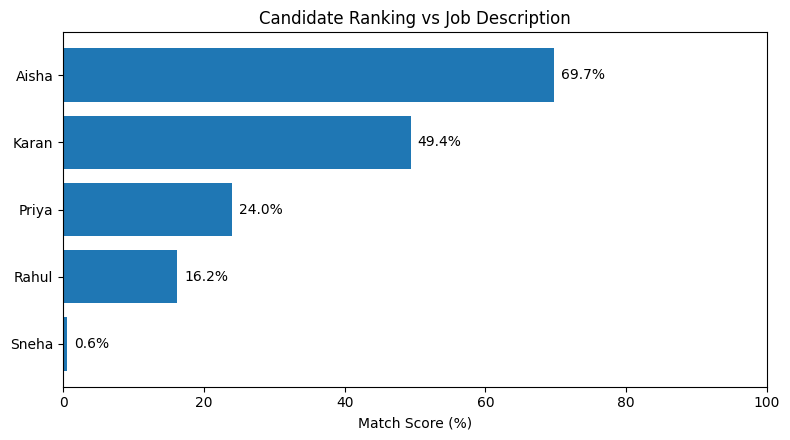

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

candidates = results_df["Candidate"]
match_pct = results_df["Match %"]

bars = ax.barh(candidates[::-1], match_pct[::-1])  # reverse so #1 is on top
ax.set_xlabel("Match Score (%)")
ax.set_title("Candidate Ranking vs Job Description")

# Label each bar with its value
for bar, value in zip(bars, match_pct[::-1]):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center")

ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 10. Evaluation — How Good Is the Ranking?

**Important honesty point for your report:** TF-IDF + cosine similarity is *not*
a trained machine-learning model. There are no labels it learns from and no
training loop — it is a deterministic, rule-based method. The only "fitting" step
is learning the vocabulary and IDF weights from the corpus.

So how do we evaluate it? With a small **labeled relevance set**. For this job we
decide (as a human "ground truth") which candidates are genuinely relevant:

- Relevant: **Aisha** (ML Engineer), **Karan** (AI Researcher)
- Not relevant: Priya, Rahul, Sneha

We then measure **precision@k** = of the top *k* ranked candidates, what fraction
are actually relevant. This is the standard metric for ranking/search systems.

In [11]:
# Ground-truth labels (1 = genuinely relevant to this ML role)
relevant = {"Aisha": 1, "Karan": 1, "Priya": 0, "Rahul": 0, "Sneha": 0}

ranked_names = [name for name, _ in ranked]

print("Precision@k (top-k candidates that are truly relevant):\n")
for k in range(1, len(ranked_names) + 1):
    top_k = ranked_names[:k]
    hits = sum(relevant[name] for name in top_k)
    precision = hits / k
    print(f"  Precision@{k} = {hits}/{k} = {precision:.2f}   (top {k}: {', '.join(top_k)})")

Precision@k (top-k candidates that are truly relevant):



  Precision@1 = 1/1 = 1.00   (top 1: Aisha)
  Precision@2 = 2/2 = 1.00   (top 2: Aisha, Karan)
  Precision@3 = 2/3 = 0.67   (top 3: Aisha, Karan, Priya)
  Precision@4 = 2/4 = 0.50   (top 4: Aisha, Karan, Priya, Rahul)
  Precision@5 = 2/5 = 0.40   (top 5: Aisha, Karan, Priya, Rahul, Sneha)


**Result:** Precision@1 and Precision@2 are both **1.00** — the system places
*both* truly-relevant candidates at the very top before any irrelevant one. That
is exactly the behavior a recruiter wants.

> Caveat: this is a tiny, illustrative labeled set (5 candidates). A real
> evaluation would use many job descriptions and many resumes with verified
> labels. Treat these numbers as a demonstration of the *method*, not a
> production benchmark.

## 11. Key Insights, Limitations & Business Implications

**Key insights**
- TF-IDF + cosine similarity produces a sensible, interpretable ranking with very
  little code and no labeled training data.
- The biggest signal comes from distinctive technical keywords (e.g. *tensorflow,
  pytorch, deep learning*), which TF-IDF up-weights automatically via IDF.

**Limitations (great discussion points)**
- It matches **keywords, not meaning.** It does not know that "ML" = "machine
  learning", or that "led a team" relates to "leadership". A candidate using
  different-but-equivalent wording can be unfairly scored low.
- It has **no understanding of context** — "no experience in Python" and
  "expert in Python" both contain the word "python".
- It can be **gamed by keyword stuffing.**

**How to improve it (future work)**
- Use **semantic embeddings** (e.g. Sentence-BERT) so synonyms and paraphrases
  match by meaning, not exact spelling.
- Extract a structured **skills list** from the JD and give explicit bonuses for
  matched must-have skills.
- Add section weighting (skills/experience weighted higher than hobbies).

**Business implications**
- Recruiters can shortlist faster and more consistently, reducing time-to-hire.
- Because the method is transparent (you can see which words drove the score), it
  is easier to audit for fairness than a black-box model — an important
  consideration for hiring tools.

**Deployment:** the accompanying `app.py` exposes this exact pipeline as an
interactive web app (built with Streamlit) where a user uploads resumes, pastes a
job description, and sees the live ranking.